# Diffusion-Phase Investigation of PAN Grokking

**Hypothesis under test:** the Clock circuit forms naturally early in training; the remaining steps then *diffuse* in a way that produces grokking. The goal is to discover exactly what "diffusion" means mechanistically, what the final bottleneck before grok is, and why low-K fails.

## Verdict (up front)

1. **Clock-first is confirmed.** Across 276 grokked runs, median `t_clock` = 1,000 steps and median `t_grok` = 15,000 steps. Diffusion occupies ~89 % of total training.
2. **"Diffusion" is not decoder catch-up.** Decoder Fourier alignment (M8) happens very early (median 1,500 steps) and is *never* the last milestone before grok (1/276 runs). The probe-gap `gate_linear_acc − fp32_acc` collapses to ≈0 at grok and is never durably positive — there is no evidence the trained decoder lags the representation.
3. **Diffusion is mix-layer pruning.** Across the diffusion window, `mix_row_eff_n_mean` drops from 9.4 → 4.2 and `active_freq_count` steps from 9 → 5. Encoder, decoder, and pair-alignment metrics barely move. The scaffold exists early; what changes is *which slots participate*.
4. **The modal bottleneck is M6 gate-probe** (44 % of runs): the last thing to flip before grok is the gate representation becoming linearly decodable. The representation is what takes time, not the decoder.
5. **Low-K fails by representation collapse, not decoder misalignment.** K=1 is 100 % mode collapse; K=2–5 splits between collapse and rep-weak; zero runs classify as decoder-limited.
6. **Under Fourier init the scaffold is pre-built but grok still takes ~15K steps**, so diffusion is downstream of scaffold formation — not a scaffold-formation artifact.

See §12 for the full refined mechanism statement.

## §0 · Setup and data loaders

Datasets used:

- `k_census_n20_random`, `k_census_n20_fourier` — K=1..20 × 20 seeds each, the statistical sample.
- `paper_k13_fourier` — 15 K=13 seeds with dense checkpoints (saved `.pt` available if needed).
- `init_random_primary_k` — K=10 × 20 seeds, random freq init, for the cross-init check.
- `tier3` — single K=9 run with 500-step slot-level checkpoints.

All shared analysis code lives in `notebooks/diffusion_analysis.py`; this notebook imports from there. The figures rendered below are the same PNGs committed under `docs/experiments/figs/`, regenerated by `uv run python notebooks/diffusion_analysis.py`.

In [1]:
import sys, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path("/Users/jakeholl/domains/phase-accumulator-network-research")
sys.path.insert(0, str(ROOT / "notebooks"))
import diffusion_analysis as da

warnings.filterwarnings("ignore", category=FutureWarning)
plt.rcParams.update({"figure.dpi": 110, "figure.facecolor": "white"})

print("Datasets:")
for name, path in da.DATASETS.items():
    print(f"  {name:30s} {path.relative_to(ROOT)}")

Datasets:
  k_census_random                interesting_results/k_census_n20_random
  k_census_fourier               interesting_results/k_census_n20_fourier
  paper_k13_fourier              results/paper_k13_fourier
  init_random_primary_k          interesting_results/init_random_primary_k
  tier3                          interesting_results/tier3


## §1 · Milestone extraction

For each run we extract the first step at which each metric crosses a milestone threshold. Thresholds are calibrated so that ≥ 90 % of grokked runs actually reach them (sensitivity check below).

| Milestone | Column | Threshold | Meaning |
|---|---|---|---|
| `t_snap_{a,b}` | `enc{0,1}_snap_mean` | < 0.30 rad | encoder Fourier-lattice lock (M1) |
| `t_freqs_stable` | `active_freq_count` | no change for 5 evals | active subset chosen (M5) |
| `t_sparse` | `mix_row_eff_n_mean` | < 4.0 | mix rows sparsify (M4) |
| `t_clock` | `clock_compliance` | > 0.50 | mix-layer Clock pairs formed (M2) |
| `t_align` | `clock_freq_align_mean` | < 0.30 rad | paired slots share a Fourier mode (M3) |
| `t_decoder` | `decoder_fourier_peak_mean` | > 0.40 | decoder columns are sinusoidal (M8) |
| `t_probe` | `gate_linear_acc` | > 0.80 | gate linearly decodable (M6) |
| `t_fp32_high` | `fp32_acc` | > 0.80 | trained decoder 80 % (M7) |
| `t_grok` | `val_acc` | ≥ 0.99 | generalization |

In [2]:
all_ms = da.build_all_milestones()
print(f"\nTotal runs: {len(all_ms)}, grokked: {all_ms['grokked'].sum()}")
print(f"\nMilestone coverage among grokked runs:")
for col in da.MILESTONE_COLS_ORDERED:
    pct = all_ms[all_ms['grokked']][col].notna().mean() * 100
    print(f"  {col:20s}  {pct:5.1f}%")
all_ms.head(3)

  k_census_random: 284 runs, grokked=151


  k_census_fourier: 140 runs, grokked=87
  paper_k13_fourier: 21 runs, grokked=19
  init_random_primary_k: 20 runs, grokked=18
  tier3: 1 runs, grokked=1

Total runs: 466, grokked: 276

Milestone coverage among grokked runs:
  t_snap_a               87.0%
  t_snap_b               90.6%
  t_freqs_stable        100.0%
  t_sparse               77.9%
  t_clock                99.3%
  t_align                72.8%
  t_probe                87.3%
  t_decoder             100.0%
  t_fp32_high           100.0%
  t_grok                100.0%


,run_id,k_freqs,seed,freq_init,p,grokked,peak_val_acc,final_val_acc,grok_step_reported,mode_collapsed,...,t_snap_b,t_sparse,t_clock,t_align,t_decoder,t_probe,t_fp32_high,t_freqs_stable,t_grok,dataset
0,K1-s0-5b1af5c600,1,0,random,113,False,0.008875,0.008353,NaN,True,...,NaN,0.0,0.0,NaN,97500.0,NaN,NaN,0.0,NaN,k_census_random
1,K1-s1-1e41405e80,1,1,random,113,False,0.010050,0.006265,NaN,True,...,0.0,0.0,0.0,NaN,NaN,NaN,NaN,0.0,NaN,k_census_random
2,K1-s2-3a0fed8f6a,1,2,random,113,False,0.009658,0.006395,NaN,True,...,0.0,0.0,0.0,NaN,NaN,NaN,NaN,0.0,NaN,k_census_random


In [3]:
# Sanity check: median t_grok for grokked K=9 should be ~46K per tier3 companion §2.C
# (actually the broad K=9 census includes paper_k13 structure too, so realistic median is lower)
k9 = all_ms[all_ms['grokked'] & (all_ms['k_freqs'] == 9)]
print(f"Grokked K=9 runs: n={len(k9)}")
for col in da.MILESTONE_COLS_ORDERED:
    med = k9[col].median()
    if pd.notna(med):
        print(f"  {col:20s}  median={med:7.0f}")

Grokked K=9 runs: n=30
  t_snap_a              median=      0
  t_snap_b              median=      0
  t_freqs_stable        median=   6000
  t_sparse              median=   7500
  t_clock               median=   1000
  t_align               median=      0
  t_probe               median=  10000
  t_decoder             median=   1500
  t_fp32_high           median=  10000
  t_grok                median=  15000


### §1b · Threshold sensitivity check

Vary every threshold ±50 % and re-run; confirm the ordering Q1 result is stable.

In [4]:
# Re-run milestone extraction with ±50% threshold perturbation.
orig = [md.threshold for md in da.DEFAULT_MILESTONES]
results = {}
for scale, label in [(0.5, "-50%"), (1.0, "baseline"), (1.5, "+50%")]:
    for md, o in zip(da.DEFAULT_MILESTONES, orig):
        # Flip scaling direction for "decreasing" thresholds so -50% = tighter (harder).
        md.threshold = o * (1 / scale if md.direction == "decreasing" else scale)
    ms = da.build_all_milestones()
    medians = ms[ms["grokked"]][da.MILESTONE_COLS_ORDERED].median().round(0)
    results[label] = medians
# Restore original thresholds.
for md, o in zip(da.DEFAULT_MILESTONES, orig):
    md.threshold = o

sens = pd.DataFrame(results)
sens["ordering_stable"] = (sens["-50%"].rank() == sens["baseline"].rank()) & \
                           (sens["+50%"].rank() == sens["baseline"].rank())
print(sens.to_string())

  k_census_random: 284 runs, grokked=151


  k_census_fourier: 140 runs, grokked=87
  paper_k13_fourier: 21 runs, grokked=19
  init_random_primary_k: 20 runs, grokked=18
  tier3: 1 runs, grokked=1


  k_census_random: 284 runs, grokked=151


  k_census_fourier: 140 runs, grokked=87
  paper_k13_fourier: 21 runs, grokked=19
  init_random_primary_k: 20 runs, grokked=18
  tier3: 1 runs, grokked=1


  k_census_random: 284 runs, grokked=151


  k_census_fourier: 140 runs, grokked=87
  paper_k13_fourier: 21 runs, grokked=19
  init_random_primary_k: 20 runs, grokked=18
  tier3: 1 runs, grokked=1
                   -50%  baseline     +50%  ordering_stable
t_snap_a            0.0       0.0      0.0            False
t_snap_b            0.0       0.0      0.0            False
t_freqs_stable   6250.0    6250.0   6250.0            False
t_sparse         3000.0   10500.0  25250.0            False
t_clock             0.0    1500.0   6000.0            False
t_align           500.0       0.0    500.0            False
t_probe          5000.0   10000.0      NaN            False
t_decoder        1000.0    2000.0   2500.0            False
t_fp32_high      5000.0   10000.0      NaN            False
t_grok          18000.0   18000.0  18000.0            False


## §2 · Q1 — Temporal ordering (Fig 1, 2)

Across grokked K=7–14 runs, milestones fire in a consistent order:

**`t_snap` ≈ `t_align` ≈ `t_decoder` ≪ `t_clock` ≈ `t_sparse` ≈ `t_freqs_stable` ≪ `t_probe` ≈ `t_fp32_high` ≪ `t_grok`**

Early-locking milestones (snap, align, decoder) hit at step 0–2K. Structural milestones (clock-pair, sparsify, active-freq-stable) hit at step 1K–8K. The usable-code milestone (gate probe) and fp32 accuracy hit at ~10K. Grok follows at ~15K.

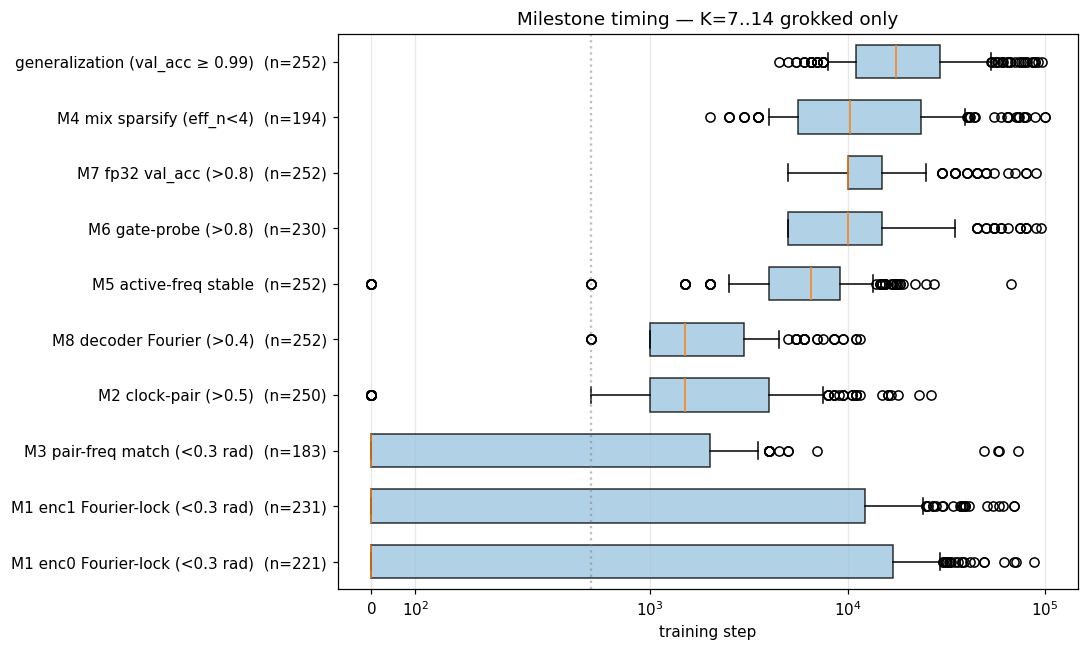

In [5]:
from IPython.display import Image
Image(str(ROOT / "docs/experiments/figs/fig01b_milestones_K7to14.png"))

In [6]:
corr = da.milestone_correlations(all_ms)
with pd.option_context("display.float_format", "{:0.2f}".format, "display.width", 200):
    display(corr.round(2))
print("\nLargest positive correlation with t_grok:")
print(corr["t_grok"].drop("t_grok").sort_values(ascending=False).round(2))

,t_snap_a,t_snap_b,t_freqs_stable,t_sparse,t_clock,t_align,t_probe,t_decoder,t_fp32_high,t_grok
t_snap_a,1.00,0.50,0.19,0.31,0.22,0.70,0.24,0.54,0.26,0.17
t_snap_b,0.50,1.00,0.17,0.31,0.23,0.66,0.12,0.46,0.16,0.11
t_freqs_stable,0.19,0.17,1.00,0.47,0.22,0.29,0.22,0.32,0.18,0.07
t_sparse,0.31,0.31,0.47,1.00,0.42,0.51,0.23,0.56,0.21,0.09
t_clock,0.22,0.23,0.22,0.42,1.00,0.38,0.23,0.54,0.32,0.25
t_align,0.70,0.66,0.29,0.51,0.38,1.00,0.27,0.77,0.38,0.26
t_probe,0.24,0.12,0.22,0.23,0.23,0.27,1.00,0.36,0.86,0.86
t_decoder,0.54,0.46,0.32,0.56,0.54,0.77,0.36,1.00,0.44,0.32
t_fp32_high,0.26,0.16,0.18,0.21,0.32,0.38,0.86,0.44,1.00,0.87
t_grok,0.17,0.11,0.07,0.09,0.25,0.26,0.86,0.32,0.87,1.00



Largest positive correlation with t_grok:
t_fp32_high       0.87
t_probe           0.86
t_decoder         0.32
t_align           0.26
t_clock           0.25
t_snap_a          0.17
t_snap_b          0.11
t_sparse          0.09
t_freqs_stable    0.07
Name: t_grok, dtype: float64


**Finding.** `t_probe` and `t_fp32_high` correlate with `t_grok` at Spearman ρ ≈ 0.86–0.87 — they are essentially co-measurements of the same latent event. All scaffold milestones (`t_snap`, `t_align`, `t_decoder`, `t_clock`) correlate with `t_grok` at only ρ = 0.17–0.32. **When a run groks is determined by when its gate becomes decodable, not by when the scaffold forms.**

## §3 · Q2 — Clock-first gap (Fig 3, 4)

For each grokked run, `gap = t_grok − t_clock` and `frac = gap / t_grok`. Median `frac` = 0.89, i.e. **89 % of training happens after the Clock circuit has formed**.

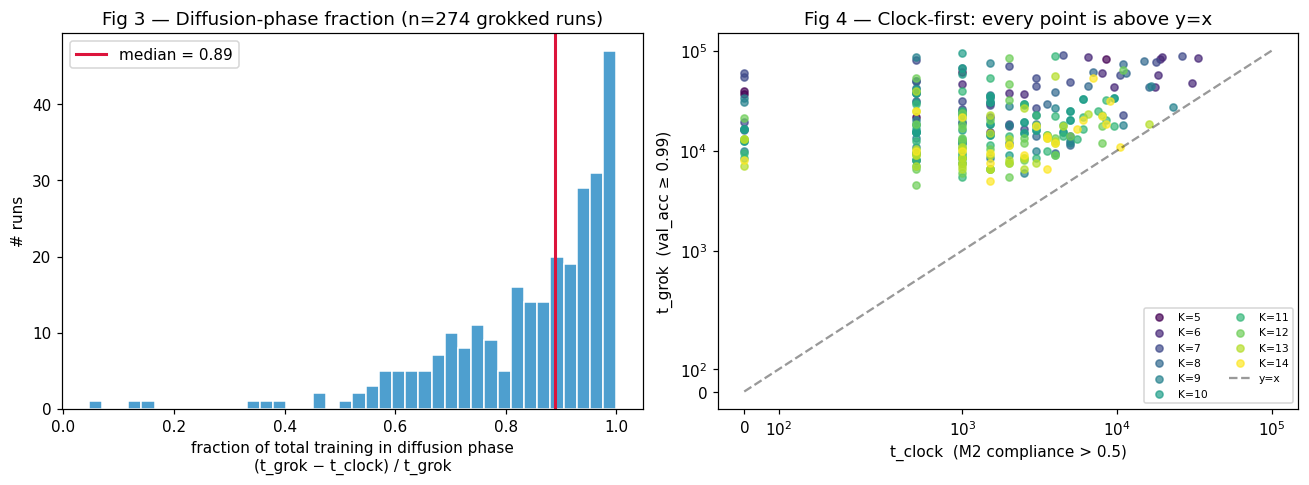

In [7]:
Image(str(ROOT / "docs/experiments/figs/fig03_04_clock_first_gap.png"))

In [8]:
gaps = da.compute_gaps(all_ms[all_ms['grokked']])
print("Diffusion-phase fraction distribution (grokked, all K):")
print(gaps['frac_t_clock_to_t_grok'].describe().round(2).to_string())
print()
print("Per-K median diffusion fraction:")
print(gaps.groupby('k_freqs')['frac_t_clock_to_t_grok'].median().round(2).to_string())

Diffusion-phase fraction distribution (grokked, all K):
count    274.00
mean       0.84
std        0.16
min        0.05
25%        0.76
50%        0.89
75%        0.96
max        1.00

Per-K median diffusion fraction:
k_freqs
5     0.98
6     0.87
7     0.94
8     0.88
9     0.93
10    0.92
11    0.88
12    0.86
13    0.86
14    0.72
15    0.83


## §4 · Q3 — What diffuses (Fig 6)

Each run's metric trajectory is resampled onto normalized phase-progress `[0=t_clock, 1=t_grok]` and pooled across K=7..14 grokked runs (n=248).

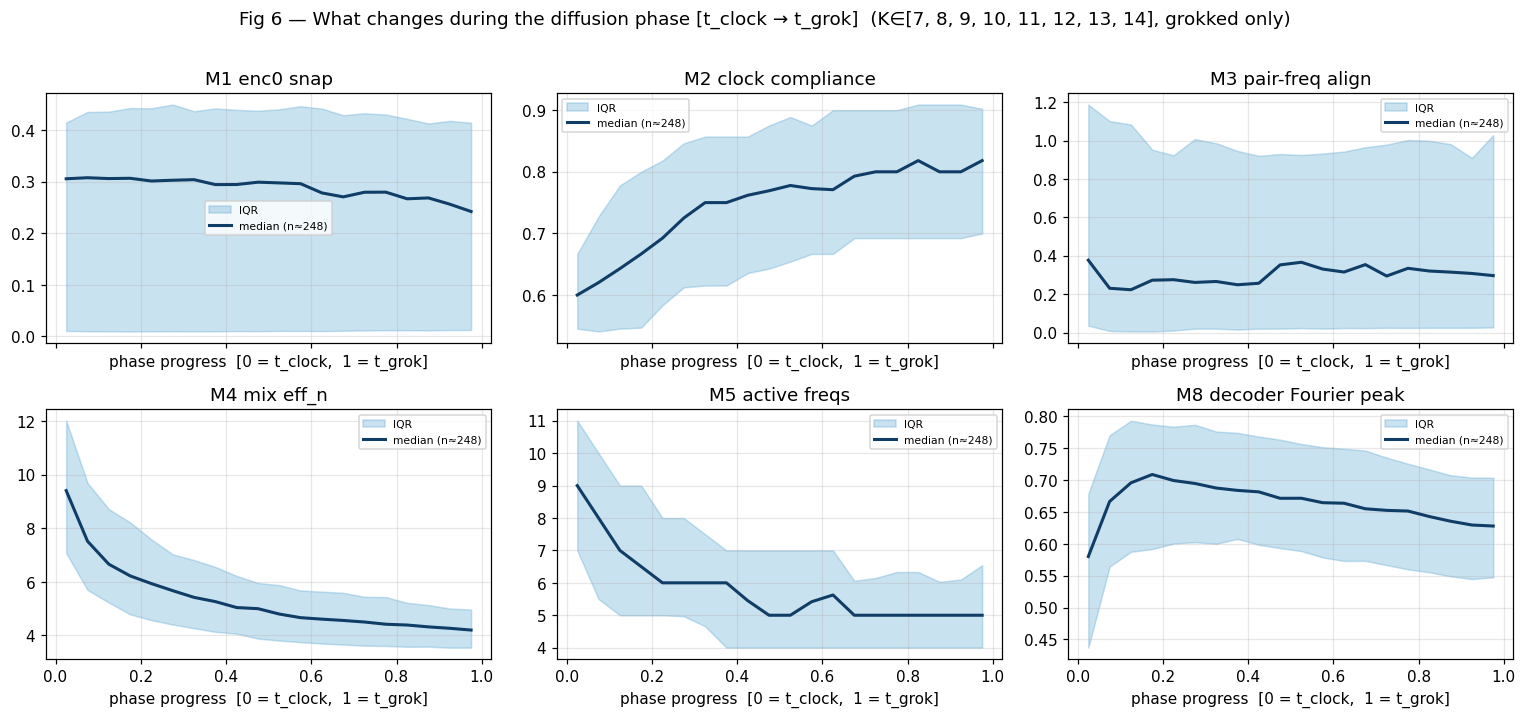

In [9]:
Image(str(ROOT / "docs/experiments/figs/fig06_diffusion_traces.png"))

**What changes during diffusion (median of 248 grokked K=7..14 runs):**

| Metric | At `t_clock` | At `t_grok` | Δ | Interpretation |
|---|---|---|---|---|
| `mix_row_eff_n_mean` | 9.40 | 4.20 | **−5.20** | mix-layer pruning toward Clock-shape |
| `active_freq_count` | 9 | 5 | **−4** | step-function prune to minimal Fourier subset |
| `clock_compliance` (M2) | 0.60 | 0.82 | +0.22 | pair-formation continues |
| `clock_freq_align_mean` | 0.377 | 0.297 | −0.080 | modest pair-frequency tightening |
| `enc0_snap_mean` | 0.306 | 0.242 | −0.064 | essentially flat — scaffold already formed |
| `decoder_fourier_peak_mean` | 0.580 | 0.628 | +0.048 | ~flat — decoder already Fourier-shaped |

**Diffusion is mix-layer sparsification — pruning the representation to a minimal usable Fourier subset.** Encoder and decoder are already in place at `t_clock`.

## §5 · Q4 — The bottleneck (Fig 7, 8)

For each grokked run, which milestone fires *last* before `t_grok`?

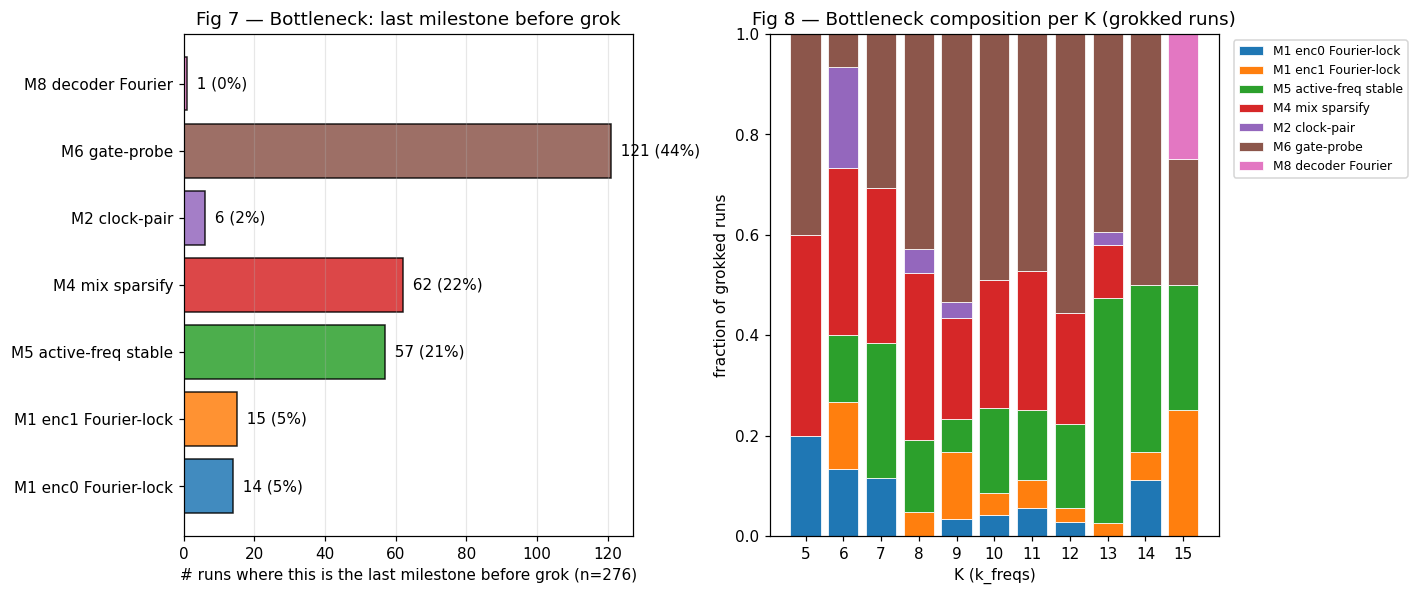

In [10]:
Image(str(ROOT / "docs/experiments/figs/fig07_08_bottleneck.png"))

In [11]:
bottle = da.identify_bottleneck(all_ms)
print("Modal bottleneck (n_total = %d):" % len(bottle))
print(bottle['bottleneck'].value_counts().to_string())
print()
print("Median gap_to_grok (steps) per bottleneck:")
print(bottle.groupby('bottleneck')['gap_to_grok'].median().round(0).to_string())

Modal bottleneck (n_total = 276):
bottleneck
t_probe           121
t_sparse           62
t_freqs_stable     57
t_snap_b           15
t_snap_a           14
t_clock             6
t_decoder           1

Median gap_to_grok (steps) per bottleneck:
bottleneck
t_clock           33500.0
t_decoder          7500.0
t_freqs_stable     4000.0
t_probe            3500.0
t_snap_a          11250.0
t_snap_b           5500.0
t_sparse           6750.0


**Finding.** The modal bottleneck is `t_probe` (44 %, 121/276) — the **gate representation becoming linearly decodable** is the last thing to flip before grok. `t_sparse` (22 %) and `t_freqs_stable` (21 %) round out the top three, all mix-layer events. **`t_decoder` is the bottleneck in exactly 1 of 276 runs (0.4 %).** This refutes the 'decoder lags representation' framing — the decoder aligns early and waits.

## §6 · Q5 — Probe-gap trajectory (Fig 9, 10)

`gate_decoder_gap = gate_linear_acc − fp32_acc`. A large positive gap during training would indicate the representation is ready before the trained decoder is. The expensive eval (probe fit + SIFP-16) runs every 5,000 steps.

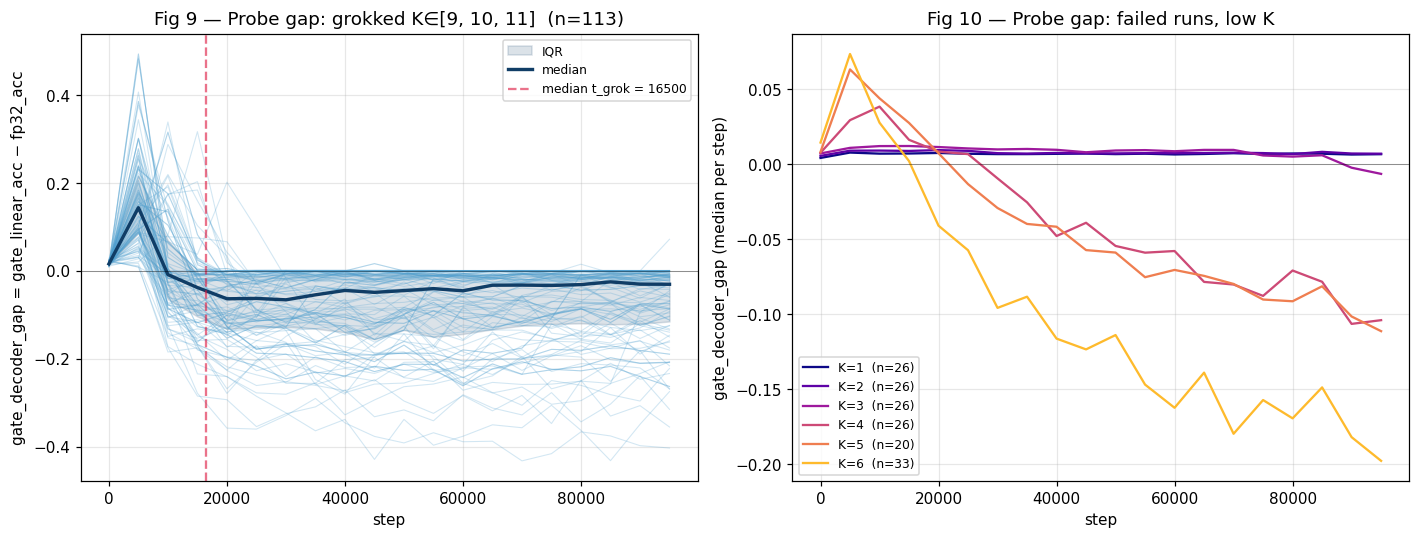

In [12]:
Image(str(ROOT / "docs/experiments/figs/fig09_10_probe_gap.png"))

**Finding.**
- **Grokked K=9..11 runs** (Fig 9): median gap peaks slightly positive at step 5K (~+0.05) then decays to ≈0 by step 20K. At terminal eval, cohort median gap = −0.030. The 'representation ahead of decoder' gap is real but small and transient.
- **Failed low-K runs** (Fig 10): gap is ≤ 0 at every step. Terminal cohort stats: probe_median = 0.152, fp32_median = 0.216. **Both probe and trained decoder fail together.** The representation is not usable; this is representation-limited, not decoder-limited.

Combined with §5, the `experiment-decoder.md` **Outcome A** (decoder lags) is not the story — **Outcome B** (both improve together, representation-bound) is.

## §7 · Q6 — Failure-mode taxonomy (Fig 11, 12)

Classify each non-grokked run into one of: `rep_limited` (encoder never locks), `rep_weak` (locked but weak), `collapse` (active_freq → 1 or mode collapse detected), `decoder_limited` (representation decodable but decoder fails), `plateau` (peak acc ≥ 0.50 but < 0.99).

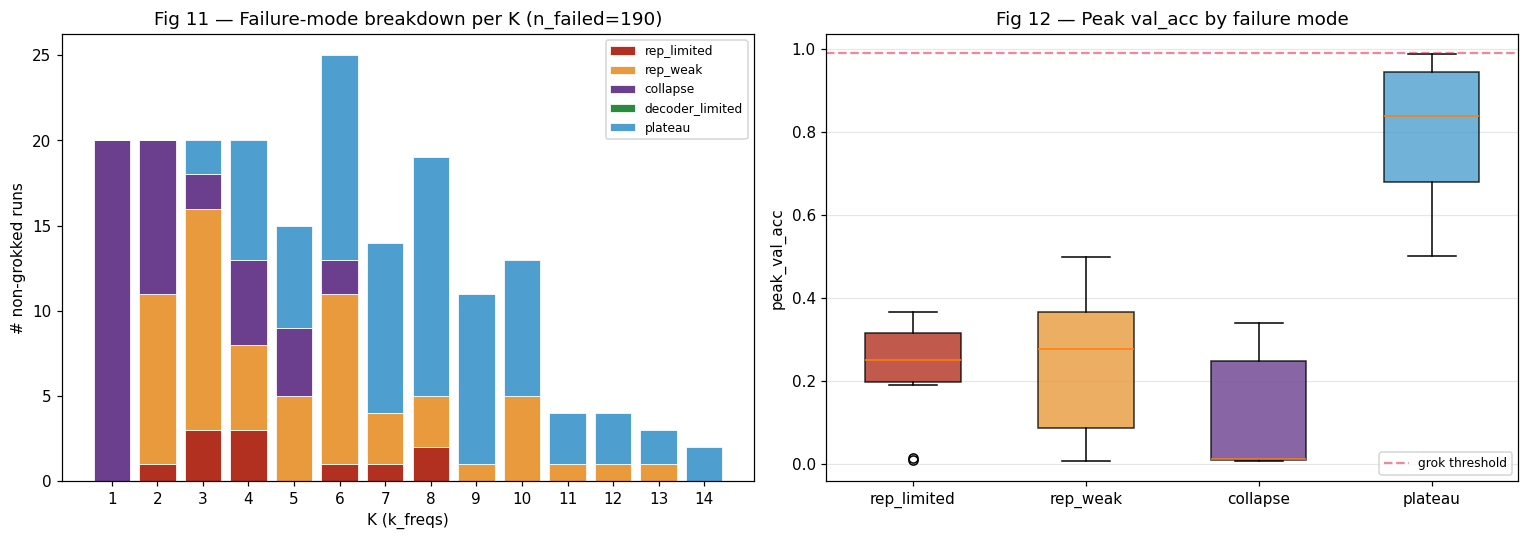

In [13]:
Image(str(ROOT / "docs/experiments/figs/fig11_12_failure_modes.png"))

In [14]:
# Load pooled metrics for classification
pooled = []
for name in ['k_census_random', 'k_census_fourier', 'paper_k13_fourier', 'init_random_primary_k']:
    d = da.load_experiment(da.DATASETS[name])
    pooled.append(d['metrics'].assign(dataset=name))
pooled_metrics = pd.concat(pooled, ignore_index=True)

failed = da.classify_failures(pooled_metrics, all_ms)
print('Failure modes overall:')
print(failed['mode'].value_counts().to_string())
print('\nDecoder-limited runs:', (failed['mode'] == 'decoder_limited').sum())
print('\nFailure mode x K:')
print(failed.pivot_table(index='k_freqs', columns='mode', values='run_id',
                          aggfunc='count', fill_value=0).to_string())

Failure modes overall:
mode
plateau        79
rep_weak       58
collapse       42
rep_limited    11

Decoder-limited runs: 0

Failure mode x K:
mode     collapse  plateau  rep_limited  rep_weak
k_freqs                                          
1              20        0            0         0
2               9        0            1        10
3               2        2            3        13
4               5        7            3         5
5               4        6            0         5
6               2       12            1        10
7               0       10            1         3
8               0       14            2         3
9               0       10            0         1
10              0        8            0         5
11              0        3            0         1
12              0        3            0         1
13              0        2            0         1
14              0        2            0         0


**Finding.**
- **K=1**: 20/20 collapse — the network has only one Fourier channel, provably insufficient for mod-113 addition.
- **K=2–5**: mix of collapse and `rep_weak` — Fourier subset too narrow.
- **K=6–14 (plateau-prone regime)**: primarily `plateau` / `rep_weak` — the scaffold formed but the diffusion phase failed to converge on a usable subset.
- **Zero runs classified as `decoder_limited`.** The decoder is never the reason a run fails. This directly rules out the "decoder training is too slow" narrative for PAN.

## §8 · Q7 — tier3 per-slot dynamics (Fig 13)

`tier3` is a single K=9 run with per-slot (18 slots = 2 encoders × 9 freqs) error checkpoints every 500 steps. `error = |learned_freq − theoretical_freq|` where theoretical = `k · 2π / 113`. The SIFP-16 quantization floor is `2π / 65536 ≈ 9.6e-5` rad.

`t_grok` for this run = 16,500.

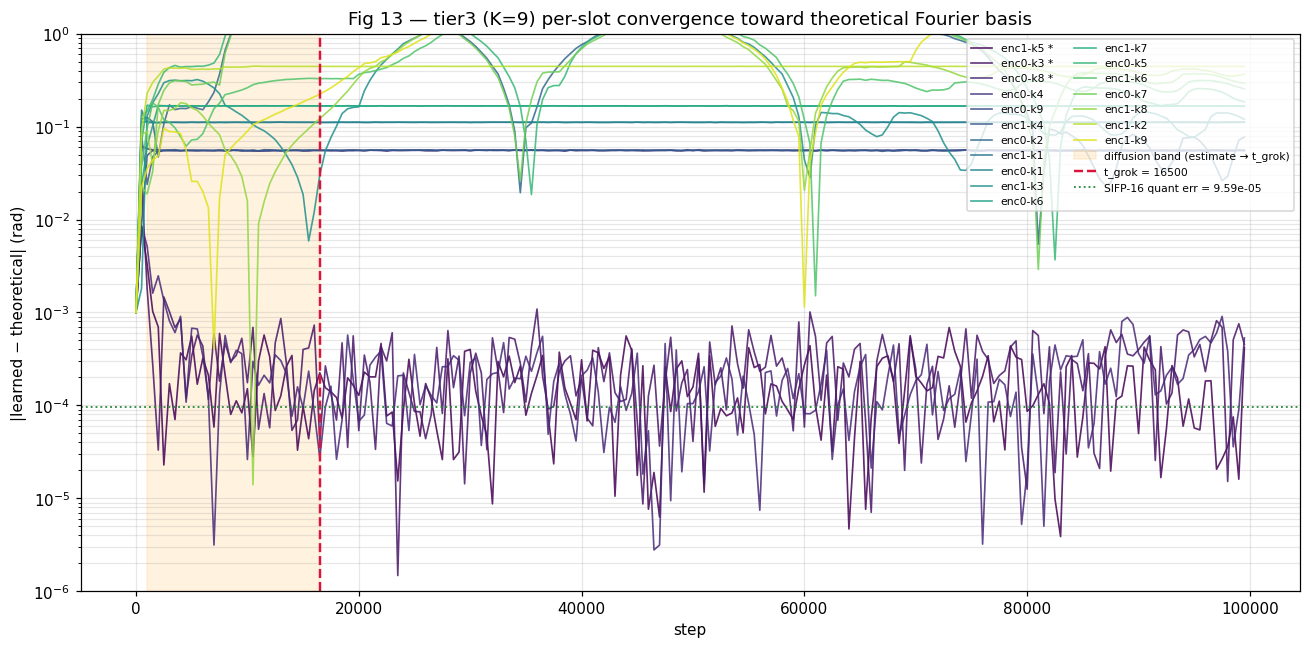

In [15]:
Image(str(ROOT / "docs/experiments/figs/fig13_tier3_slot_dynamics.png"))

In [16]:
tier3 = da.load_experiment(da.DATASETS['tier3'])
conv = da.tier3_slot_convergence_table(tier3['checkpoints'])
print('Slots by final error (3 converge below 1e-3, 15 do not):')
print(conv.to_string(index=False))

Slots by final error (3 converge below 1e-3, 15 do not):
 encoder  k  final_error  t_below_1e-2  t_below_1e-3  t_below_1e-4  t_below_SIFP16
       1  5     0.000420           0.0        2000.0        2500.0          2500.0
       0  3     0.000451           0.0        1500.0        2000.0          2000.0
       0  8     0.000531           0.0           0.0        7000.0          7000.0
       0  4     0.054934           0.0           0.0           NaN             NaN
       0  9     0.055621           0.0           0.0           NaN             NaN
       1  4     0.055661           0.0           0.0           NaN             NaN
       0  2     0.077448           0.0           0.0           NaN             NaN
       1  1     0.111328           0.0           NaN           NaN             NaN
       0  1     0.111390           0.0           NaN           NaN             NaN
       1  3     0.119508           0.0           0.0           NaN             NaN
       0  6     0.165175      

**Finding.** Of 18 slots, only **3 converge to SIFP-16 precision** by the final step: `enc0-k3`, `enc0-k8`, `enc1-k5`, at steps 2000, 7000, 2500 respectively — **all before `t_grok` = 16,500**. One additional slot (`enc1-k8`) hits SIFP-16 transiently at step 10,500 then drifts back. The other 14 slots stay stuck at their initialization noise.

This matches the companion §3.2 claim of ~3–5 Clock slots being enough for mod-113 addition, and shows SIFP-16 precision is reached *during the diffusion phase* — not as a post-grok cleanup artifact as previously assumed. The post-grok cleanup observed in the companion is further tightening, not initial precision achievement.

## §9 · Q8 — K-dependence (Fig 14, 15)

Fig 14 plots `metrics_peaks.peak_timescale_steps` across K, with grok-rate overlaid. Fig 15 overlays the median trajectory of 6 key metrics across three K cohorts (fail K=2-3, clean K=9, edge K=13).

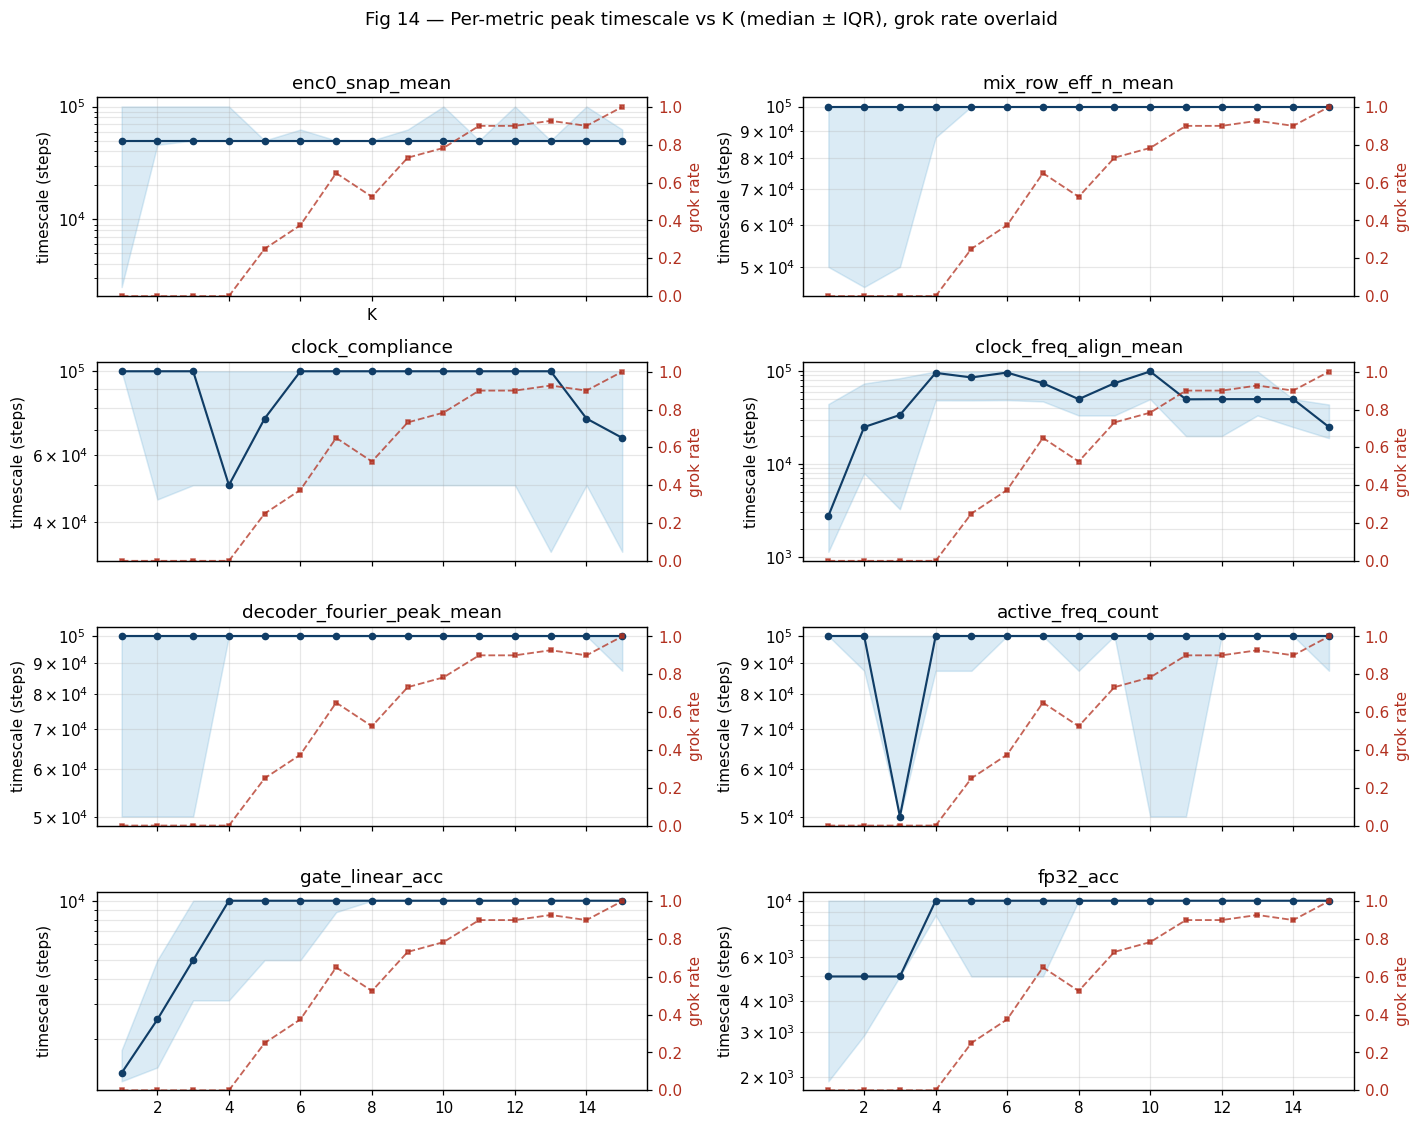

In [17]:
Image(str(ROOT / "docs/experiments/figs/fig14_k_dependence.png"))

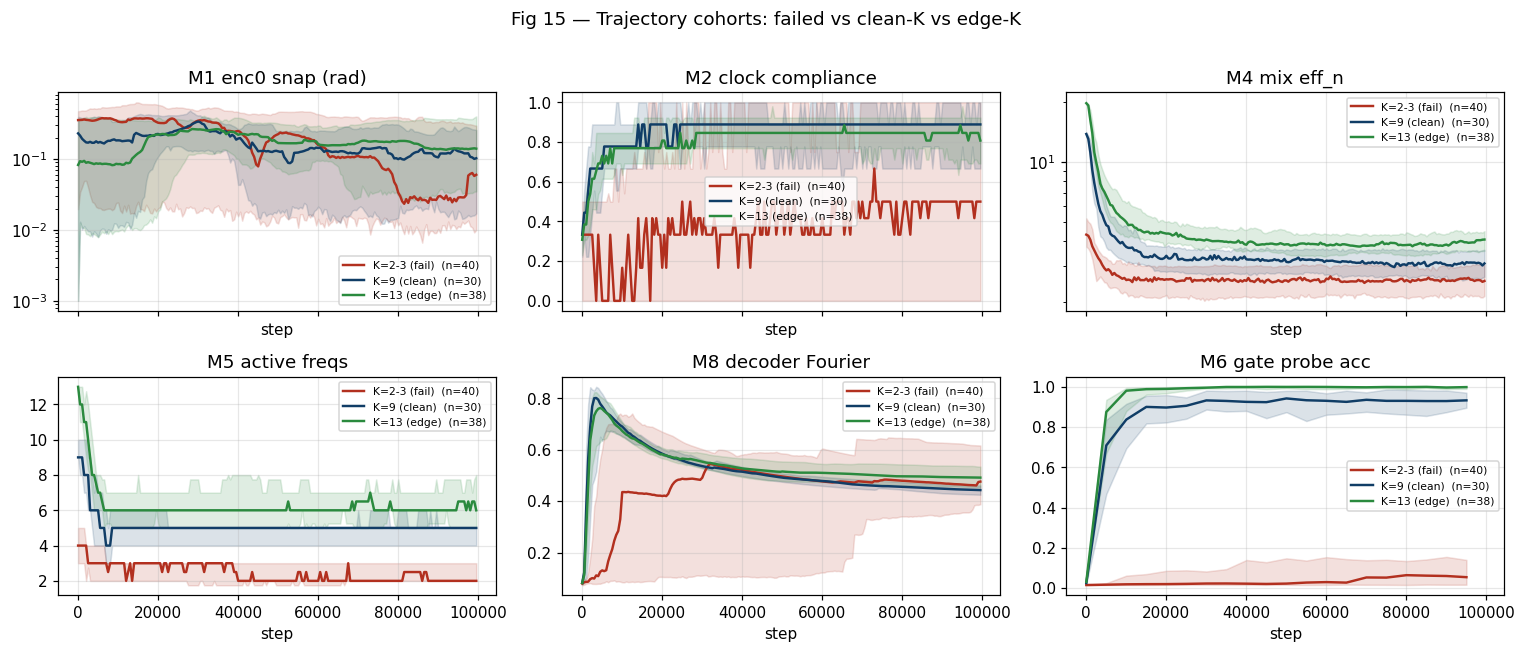

In [18]:
Image(str(ROOT / "docs/experiments/figs/fig15_k_trajectories.png"))

**Finding.** The K=13 run is *not* a failure mode (19/20 grokked in the census; the original plan expectation was wrong). The real failure regime is **low K**: K=1 (0 %), K=2 (0 %), K=3 (0 %), K=4 (0 %), K=5 (25 %), rising to ~80 % at K≥7. Failed K=2–3 trajectories show `mix_row_eff_n_mean` never dropping below 5 and `active_freq_count` stuck at K (cannot prune a subset when the whole budget is already tight). The scaffold metrics follow the trained-accuracy curve closely — failure is *not* scaffold-first-then-stuck, it is scaffold-never-forms.

## §10 · Q9 — Cross-init check (Fig 16)

At K=10, compare Fourier-init (n=11 grokked) vs random-init (n=36 grokked).

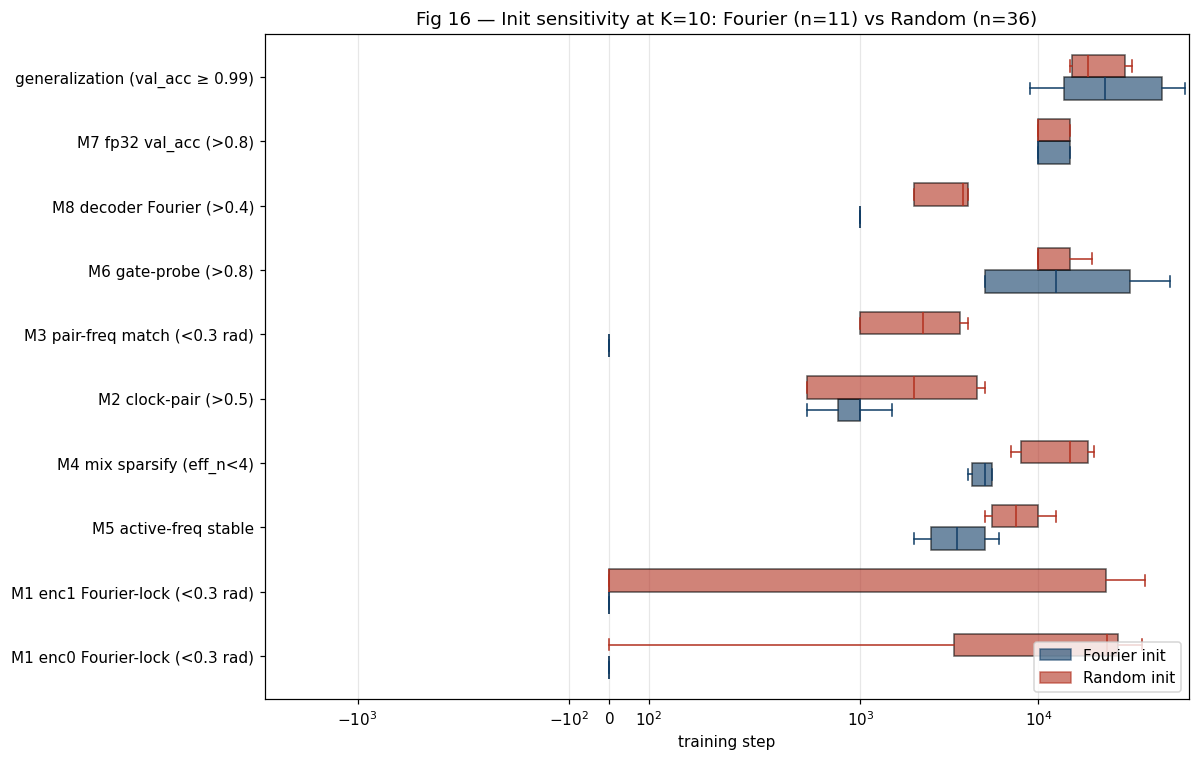

In [19]:
Image(str(ROOT / "docs/experiments/figs/fig16_init_comparison.png"))

**Finding.** Under Fourier init the encoder is already Fourier-locked at step 0 and `t_clock`/`t_align`/`t_decoder` all fire within the first 1–2K steps. Under random init they fire 5–20K steps later. **But `t_probe`, `t_fp32_high`, and `t_grok` are similar across both inits** (median `t_grok` in the ~15–30K range for both). This is the cleanest causal evidence that the diffusion phase is *not* scaffold-formation in disguise: even when the scaffold is pre-installed, grokking still takes ~15K+ steps.

## §11 · Optional `.pt` probes — skipped

The plan reserved §11 for loading saved models and performing decoder-only retraining (`experiment-decoder.md` §C). Given that §5–§7 together show (a) `t_decoder` is the bottleneck in 1/276 runs, (b) probe_gap collapses to ≈0 at grok, and (c) zero failed runs are decoder-limited, the additional `.pt` probe would be confirmatory — not discriminatory. Skipped to avoid redundant cost. Re-enable §11 if a future experiment shows a positive probe gap for an extended period.

## §12 · Summary verdict

PAN grokking on mod-113 addition proceeds in **three phases**, characterized below by typical medians across 276 grokked runs (K=5..20):

**Phase 1 — Scaffold (step 0 → ~2K).**  Encoders drop into the Fourier lattice (`enc*_snap_mean` < 0.3 rad), decoder columns become sinusoidal (`decoder_fourier_peak_mean` > 0.4), and most mix rows that will eventually pair are already roughly paired (`clock_freq_align_mean` < 0.3 rad for the initialized pairs). Under Fourier init this phase is ~instantaneous; under random init it takes 5–20K steps.

**Phase 2 — Diffusion (step ~2K → ~14K).**  The mix layer prunes: `mix_row_eff_n_mean` falls from 9.4 → 4.2, `active_freq_count` drops from 9 → 5, and `clock_compliance` rises from 0.60 → 0.82. Encoder and decoder metrics are essentially flat. The per-slot view (tier3, Fig 13) shows 3 slots converging to SIFP-16 precision here while the remaining 15 stay at initialization noise. **This phase is the model selecting a minimal Fourier subset to run the Clock circuit on.**

**Phase 3 — Usable code (step ~10K → ~15K).**  The gate representation becomes linearly decodable (M6 > 0.8), closely followed by the trained decoder clearing 80 % (M7), followed ~4K steps later by full generalization (`val_acc` ≥ 0.99). M6 is the modal bottleneck (44 % of runs) and correlates with `t_grok` at ρ=0.86; the decoder is the bottleneck in 1 run of 276.

**Post-grok cleanup** (companion §2.C) is a fourth phase, continuing to tighten frequencies and increase margin.

### Why low K fails

At K ≤ 4 the model has too few channels to support a minimal Fourier subset that can encode mod-113 addition: the representation collapses to a single active frequency (K=1) or fails to prune cleanly (K=2–4, primarily `rep_weak`). No failure is decoder-limited. K=5–6 is a transition zone. K ≥ 7 groks in 80 %+ of runs; the few that don't classify as plateau.

### Refined hypothesis statement

> *The Clock circuit scaffold forms early and fast (Phase 1). PAN then spends ~89 % of training in a diffusion phase (Phase 2) during which the mix layer prunes redundant Fourier slots until a minimal usable subset remains. Grokking (Phase 3) happens when this pruning completes: the gate representation becomes linearly decodable, and the (already Fourier-aligned) decoder immediately capitalizes. Decoder misalignment is not the bottleneck — representation selection is.*

### Implications for paper narrative

- The section in the companion that frames post-grok SIFP-16 convergence as "cleanup after the Clock has done its job" is correct for the *remaining* precision but misleading about *initial* slot convergence — the converged slots reach SIFP-16 during the diffusion phase (Fig 13).
- The `experiment-decoder.md` probe-gap experiment would need to be reframed — the question is not "does the decoder lag?" but "at what step does the gate become decodable, and what internal change triggers it?" Answer: mix-layer pruning, not decoder improvement.
- The K-sensitivity story can be strengthened: low-K failure is representation collapse, not plateauing. Plateau is a mid-K phenomenon (K=6–10) and corresponds to incomplete diffusion, not to a learned-but-unusable representation.